In [1]:
import sys
print(sys.executable)

/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/bin/python


In [21]:
# imports
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np
from keras.preprocessing.sequence import pad_sequences

In [2]:
# view the three datasets
import pandas as pd
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

TRANSCRIPTS_PATH = Path("..") / "data" / "transcripts_cleaned.csv"

In [3]:
transcript_df = pd.read_csv(TRANSCRIPTS_PATH)
print(transcript_df.shape)
transcript_df.head()

(157, 6)


,Record-ID,Class,Transcript_PFT,Transcript_CTD,Transcript_SFT,Label
0,Process-rec-001,MCI,"people, partner, plate, platter, pants, porter...",NaN,"<pause_medium> giraffe, kangaroo, lion, tiger,...",1
1,Process-rec-002,MCI,"<pause_short> pipe, plane, people <pause_mediu...",<pause_medium> there’s a lad stood on the stoo...,"<pause_short> dogs, cats, birds <pause_short> ...",1
2,Process-rec-003,MCI,"um <pause_short> purple, pale, placid <pause_s...","<pause_medium> um, the picture is of a kitchen...","cow, bull, ewe, ram, chicken, goose, um <sigh>...",1
3,Process-rec-004,MCI,plank <pause_short> pool <pause_short> swimmin...,"a mother presumably, or a fe, an adult female ...",um <pause_short> impala <pause_short> er cheet...,1
4,Process-rec-005,MCI,"it’s er pillock, er post box, er pyracanthas, ...","‘50s style er scene of domestic um confusion, ...","dog, cat, giraffe, wallaby, kangaroo, tortoise...",1


In [4]:
TRANSCRIPT_COLS = ["Transcript_PFT", "Transcript_CTD", "Transcript_SFT"]

print("NaN counts per transcript type: ")
for col in TRANSCRIPT_COLS:
    n_nans = transcript_df[col].isna().sum()
    print(f"{col}: {n_nans} NaNs")

NaN counts per transcript type: 
Transcript_PFT: 0 NaNs
Transcript_CTD: 1 NaNs
Transcript_SFT: 5 NaNs


In [53]:
transcript_df.columns

Index(['Record-ID', 'Class', 'Transcript_PFT', 'Transcript_CTD',
       'Transcript_SFT', 'Label'],
      dtype='object')

In [57]:
pft_df = transcript_df[["Transcript_PFT", "Label"]]
ctd_df = transcript_df[['Transcript_CTD', 'Label']]
sft_df = transcript_df[['Transcript_SFT', 'Label']]

In [64]:
print("Phonemic Fluency Test \n", pft_df.head)

Phonemic Fluency Test 
 <bound method NDFrame.head of                                         Transcript_PFT  Label
0    people, partner, plate, platter, pants, porter...      1
1    <pause_short> pipe, plane, people <pause_mediu...      1
2    um <pause_short> purple, pale, placid <pause_s...      1
3    plank <pause_short> pool <pause_short> swimmin...      1
4    it’s er pillock, er post box, er pyracanthas, ...      1
..                                                 ...    ...
152  um, precise, prescient, er procrastination, pr...      0
153  picture, plate, palm, photo, psychology, um <p...      0
154  countries beginning with p: paraguay, portugal...      0
155  phew, phew, phew <pause_long> phidi, philadelp...      2
156  <pause_medium> er <pause_short> paternity, pet...      0

[157 rows x 2 columns]>


In [63]:
print("Category Test: Delayed Recall \n", ctd_series.head)

Category Test: Delayed Recall 
 <bound method NDFrame.head of 0                                                    NaN
1      <pause_medium> there’s a lad stood on the stoo...
2      <pause_medium> um, the picture is of a kitchen...
3      a mother presumably, or a fe, an adult female ...
4      ‘50s style er scene of domestic um confusion, ...
                             ...                        
152    the sink is overflowing; the woman doing the w...
153    i see a scene of absolute chaos in this pictur...
154    little boy falling off a chair whilst passing ...
155    <pause_medium> er, little boy stood on a stool...
156    <pause_medium> ok, well there’s a boy stood on...
Name: Transcript_CTD, Length: 152, dtype: object>


In [62]:
print("Semantic Fluency Test \n", sft_df.head)

Semantic Fluency Test 
 <bound method NDFrame.head of                                         Transcript_SFT  Label
0    <pause_medium> giraffe, kangaroo, lion, tiger,...      1
1    <pause_short> dogs, cats, birds <pause_short> ...      1
2    cow, bull, ewe, ram, chicken, goose, um <sigh>...      1
3    um <pause_short> impala <pause_short> er cheet...      1
4    dog, cat, giraffe, wallaby, kangaroo, tortoise...      1
..                                                 ...    ...
152  um, well er cat, dog, rabbit, hamster, guinea ...      0
153  cat, lion, tiger oh. cat, lion, tiger, elephan...      0
154  horse, dog, cat, pig, hen <pause_short> walrus...      0
155  pig, cat, dog pig, cat, dog <pause_short> gira...      2
156  ooh. armadillo, antelope, bear, buffalo, er <p...      0

[157 rows x 2 columns]>


In [71]:
from typing import Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [119]:
def train_eval_log_reg_text_only(
    df: pd.DataFrame,
    text_col: str,
    label_col: str,
    test_size: float = 0.2,
    random_state: int = 42,
    do_cv: bool = True,
    cv_splits: int = 5,
) -> Tuple[Pipeline, Optional[np.ndarray], float, float]:
    """
    Text-only logistic regression pipeline.

    df:         DataFrame with text + label
    text_col:   name of the text column
    label_col:  name of the label column (e.g., 'Class_label')
    """

    # 1. Drop rows with missing text or label
    df = df.dropna(subset=[text_col, label_col]).copy()

    # 2. X and y
    X = df[[text_col]]
    y = df[label_col]

    # 3. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    # 4. Preprocessing: TF-IDF on the text column
    text_transformer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=10000,
    )

    preprocess = ColumnTransformer(
        transformers=[
            ("text", text_transformer, text_col),
        ],
        remainder="drop",
    )

    # 5. Logistic Regression model
    log_reg = LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1,

    )

    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("logreg", log_reg),
    ])

    # 6. Fit on train split
    clf.fit(X_train, y_train)

    # 7. Evaluate on test split
    y_pred = clf.predict(X_test)
    print(f"=== {text_col} — hold-out test set ===")
    print(classification_report(y_test, y_pred))

    # Confusion matrix at the end of evaluation
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix (rows = true, cols = predicted):")
    print(cm)

    # 8. Optional: cross-validation on full data
    cv_scores = None
    cv_mean = np.nan
    cv_std = np.nan

    if do_cv:
        cv = StratifiedKFold(
            n_splits=cv_splits,
            shuffle=True,
            random_state=random_state,
        )
        cv_scores = cross_val_score(
            clf,
            X,
            y,
            cv=cv,
            scoring="f1_macro",  # or "accuracy"
            n_jobs=-1,
        )
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()

        print(f"\nCV scores ({cv_splits}-fold, f1_macro): {cv_scores}")
        print(f"Mean CV: {cv_mean:.4f} ± {cv_std:.4f}")

    return clf, cv_scores, cv_mean, cv_std


In [120]:
from typing import Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# import Meggan's function
from transcript_preprocessing import get_stratified_kfold_splits  # <-- update path


def train_eval_log_reg_text_only(
    df: pd.DataFrame,
    text_col: str,
    label_col: str,
    n_splits: int = 5,
    random_state: int = 42,
    do_cv: bool = True,
) -> Tuple[Pipeline, Optional[np.ndarray], float, float]:
    """
    Text-only logistic regression pipeline that uses Meggan's
    get_stratified_kfold_splits for both:
      - the main hold-out evaluation (using the first fold)
      - optional cross-validation over all folds.

    df:         DataFrame with text + label
    text_col:   name of the text column
    label_col:  name of the label column (e.g., 'Class' or 'Label')
    """

    # 1. Drop rows with missing text or label
    df = df.dropna(subset=[text_col, label_col]).copy()

    # 2. Build X and y once
    X_all = df[[text_col]]      # DataFrame with a single column
    y_all = df[label_col]

    # 3. Preprocessing: TF-IDF on the text column
    text_transformer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=10000,
    )

    preprocess = ColumnTransformer(
        transformers=[
            ("text", text_transformer, text_col),
        ],
        remainder="drop",
    )

    # 4. Logistic Regression model
    log_reg = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
    )

    base_clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("logreg", log_reg),
    ])

    # -------- A. Hold-out evaluation using FIRST fold from Meggan’s splitter --------
    # This will match how Meggan splits for the other models.
    splits = list(
        get_stratified_kfold_splits(
            transcript_df=df,
            transcript_col=text_col,
            label_col=label_col,
            n_splits=n_splits,
            seed=random_state,
        )
    )

    # Use the first fold as our "test" split, rest as "train".
    first_fold_idx, train_idx, test_idx = splits[0]

    X_train = X_all.iloc[train_idx]
    y_train = y_all.iloc[train_idx]
    X_test = X_all.iloc[test_idx]
    y_test = y_all.iloc[test_idx]

    # Fit a fresh copy of the pipeline on this train split
    clf = clone(base_clf)
    clf.fit(X_train, y_train)

    # Evaluate on this fold's test set
    y_pred = clf.predict(X_test)
    print(f"=== {text_col} — fold {first_fold_idx} hold-out test set ===")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix (rows = true, cols = predicted):")
    print(cm)

    # -------- B. Cross-validation over ALL folds using Meggan’s splitter --------
    cv_scores = None
    cv_mean = np.nan
    cv_std = np.nan

    if do_cv:
        fold_scores = []

        for fold_idx, train_idx_cv, test_idx_cv in get_stratified_kfold_splits(
            transcript_df=df,
            transcript_col=text_col,
            label_col=label_col,
            n_splits=n_splits,
            seed=random_state,
        ):
            X_tr = X_all.iloc[train_idx_cv]
            y_tr = y_all.iloc[train_idx_cv]
            X_te = X_all.iloc[test_idx_cv]
            y_te = y_all.iloc[test_idx_cv]

            # fresh clone each fold to avoid leakage between folds
            clf_fold = clone(base_clf)
            clf_fold.fit(X_tr, y_tr)

            y_pred_fold = clf_fold.predict(X_te)
            f1_macro = f1_score(y_te, y_pred_fold, average="macro")
            fold_scores.append(f1_macro)

            print(f"[CV] Fold {fold_idx}: f1_macro = {f1_macro:.4f}")

        cv_scores = np.array(fold_scores)
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()

        print(f"\nCV scores ({n_splits}-fold, f1_macro): {cv_scores}")
        print(f"Mean CV: {cv_mean:.4f} ± {cv_std:.4f}")

    return clf, cv_scores, cv_mean, cv_std


In [87]:
from typing import Tuple, Optional, List

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.base import clone
from transcript_preprocessing import get_stratified_kfold_splits

def train_eval_log_reg_text_only_kfold(
    df: pd.DataFrame,
    text_col: str,
    label_col: str,
    n_splits: int = 5,
    random_state: int = 42,
) -> Tuple[Pipeline, np.ndarray, float, float]:
    """
    Text-only logistic regression, using ONLY Meggan's get_stratified_kfold_splits
    for splitting. No 80/20 train_test_split is used.

    For each fold:
      - fit on the training indices
      - evaluate on the test indices
      - print classification report + confusion matrix
      - record macro F1

    At the end:
      - print mean/std of macro F1 across folds
      - retrain the final model on ALL data
      - return (final_model, fold_scores, mean_f1, std_f1)
    """

    # 1. Drop rows with missing text or label
    df = df.dropna(subset=[text_col, label_col]).copy().reset_index(drop=True)

    # 2. X and y (keep X as a DataFrame so ColumnTransformer can see column names)
    X = df[[text_col]]
    y = df[label_col]

    # 3. Define preprocessing: TF-IDF on the text column
    text_transformer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=10000,
    )

    preprocess = ColumnTransformer(
        transformers=[
            ("text", text_transformer, text_col),
        ],
        remainder="drop",
    )

    # 4. Base Logistic Regression model
    base_log_reg = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
    )

    base_clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("logreg", base_log_reg),
    ])

    # 5. Use Meggan's helper to get stratified folds
    #    (this assumes get_stratified_kfold_splits is already defined/imported)
    splits = list(
        get_stratified_kfold_splits(
            transcript_df=df,
            transcript_col=text_col,
            label_col=label_col,
            n_splits=n_splits,
            seed=random_state,
        )
    )

    fold_scores: List[float] = []

    for fold_idx, train_idx, test_idx in splits:
        print(f"\n=== Fold {fold_idx} / {n_splits} ===")

        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        # Clone the pipeline so each fold starts fresh
        clf_fold = clone(base_clf)
        clf_fold.fit(X_train, y_train)

        y_pred = clf_fold.predict(X_test)

        # Classification report for this fold
        print(classification_report(y_test, y_pred))

        # Confusion matrix for this fold
        cm = confusion_matrix(y_test, y_pred)
        print("Confusion matrix (rows = true, cols = predicted):")
        print(cm)

        # Macro F1 for this fold
        f1 = f1_score(y_test, y_pred, average="macro")
        fold_scores.append(f1)
        print(f"Fold {fold_idx} macro F1: {f1:.4f}")

    fold_scores = np.array(fold_scores)
    mean_f1 = fold_scores.mean()
    std_f1 = fold_scores.std()

    print(f"\n=== Overall ({n_splits}-fold, using Meggan's splits) ===")
    print(f"Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

    # 6. Retrain final model on ALL data using the same pipeline + hyperparameters
    final_clf = clone(base_clf)
    final_clf.fit(X, y)

    return final_clf, fold_scores, mean_f1, std_f1

In [91]:
from typing import List, Dict, Tuple
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
)

# assumes get_stratified_kfold_splits is already imported


def run_cv_collect_predictions_logreg(
    transcript_col: str,
    df: pd.DataFrame,
    label_col: str = "Label",
    n_splits: int = 5,
    seed: int = 42,
    C: float = 10.0,          # or whatever C you liked from grid search
) -> Tuple[np.ndarray, np.ndarray, List[Dict]]:
    """
    Stratified K-fold CV for TF-IDF + Logistic Regression.

    For each fold:
      - build a fresh pipeline
      - fit on train indices
      - predict on val indices
      - store y_true, y_pred, and per-fold metrics

    Returns:
        y_true_all, y_pred_all, fold_metrics
    """

    # Drop NaNs and reset index for safety
    df = df.dropna(subset=[transcript_col, label_col]).copy().reset_index(drop=True)

    X = df[[transcript_col]]   # keep as DataFrame so ColumnTransformer sees col name
    y = df[label_col].values

    all_true = []
    all_pred = []
    fold_metrics: List[Dict] = []

    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df,
        transcript_col=transcript_col,
        label_col=label_col,
        n_splits=n_splits,
        seed=seed,
    ):
        # Split
        X_train = X.iloc[train_idx]
        y_train = y[train_idx]
        X_val = X.iloc[val_idx]
        y_val = y[val_idx]

        # --- Build pipeline for this fold ---
        text_transformer = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=2,
            max_features=10000,
        )

        preprocess = ColumnTransformer(
            transformers=[
                ("text", text_transformer, transcript_col),
            ],
            remainder="drop",
        )

        log_reg = LogisticRegression(
            solver="lbfgs",
            C=C,
            max_iter=1000,
            class_weight="balanced",
            n_jobs=-1,
        )

        clf = Pipeline(steps=[
            ("preprocess", preprocess),
            ("logreg", log_reg),
        ])

        # Fit
        clf.fit(X_train, y_train)

        # Predict on this fold's validation set
        y_pred = clf.predict(X_val)

        all_true.append(y_val)
        all_pred.append(y_pred)

        # Per-fold metrics
        acc = accuracy_score(y_val, y_pred)
        macro_f1 = f1_score(y_val, y_pred, average="macro", zero_division=0)
        weighted_f1 = f1_score(y_val, y_pred, average="weighted", zero_division=0)
        precision_macro, recall_macro, _, _ = precision_recall_fscore_support(
            y_val, y_pred, average="macro", zero_division=0
        )

        fold_metrics.append(
            {
                "fold": fold_idx,
                "accuracy": acc,
                "macro_f1": macro_f1,
                "weighted_f1": weighted_f1,
                "precision_macro": precision_macro,
                "recall_macro": recall_macro,
            }
        )

    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)

    return y_true_all, y_pred_all, fold_metrics



Confusion matrix for Transcript_PFT:


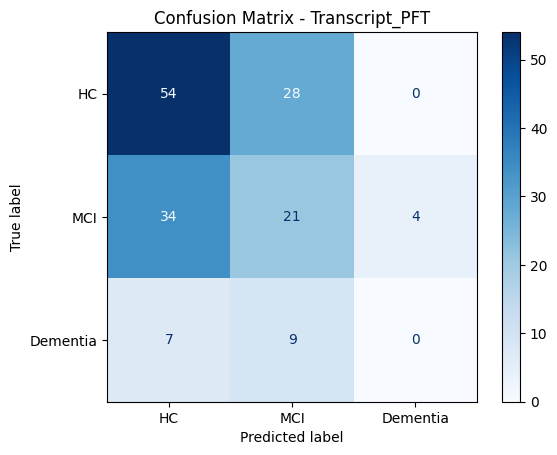

Classification report:
              precision    recall  f1-score   support

          HC       0.57      0.66      0.61        82
         MCI       0.36      0.36      0.36        59
    Dementia       0.00      0.00      0.00        16

    accuracy                           0.48       157
   macro avg       0.31      0.34      0.32       157
weighted avg       0.43      0.48      0.45       157

Mean accuracy over folds: 0.477
Mean macro F1 over folds: 0.321

Confusion matrix for Transcript_CTD:


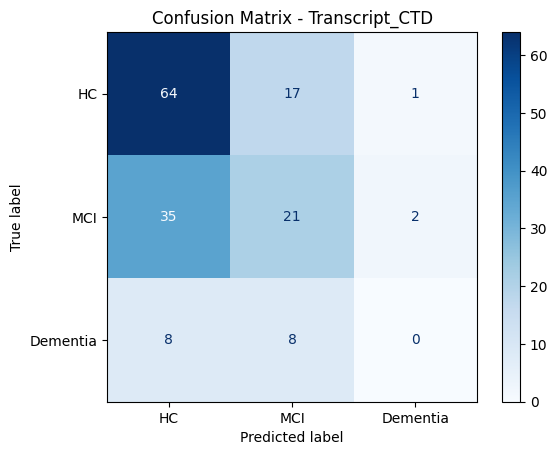

Classification report:
              precision    recall  f1-score   support

          HC       0.60      0.78      0.68        82
         MCI       0.46      0.36      0.40        58
    Dementia       0.00      0.00      0.00        16

    accuracy                           0.54       156
   macro avg       0.35      0.38      0.36       156
weighted avg       0.48      0.54      0.51       156

Mean accuracy over folds: 0.544
Mean macro F1 over folds: 0.351

Confusion matrix for Transcript_SFT:


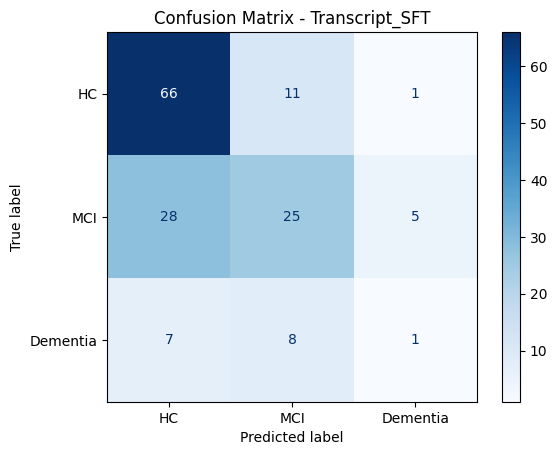

Classification report:
              precision    recall  f1-score   support

          HC       0.65      0.85      0.74        78
         MCI       0.57      0.43      0.49        58
    Dementia       0.14      0.06      0.09        16

    accuracy                           0.61       152
   macro avg       0.45      0.45      0.44       152
weighted avg       0.57      0.61      0.57       152

Mean accuracy over folds: 0.605
Mean macro F1 over folds: 0.433


In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

CLASS_NAMES = ["HC", "MCI", "Dementia"]
TRANSCRIPT_COLS = ["Transcript_PFT", "Transcript_CTD", "Transcript_SFT"]

for transcript_col in TRANSCRIPT_COLS:
    print(f"\nConfusion matrix for {transcript_col}:")

    df = df_by_transcript[transcript_col]   # your PFT/CTD/SFT-specific DF

    y_true, y_pred, fold_metrics = run_cv_collect_predictions_logreg(
        transcript_col=transcript_col,
        df=df,
        label_col="Label",
        n_splits=5,
        seed=42,
        C=10.0,   # match your best C from grid search
    )

    # Confusion matrix over ALL held-out examples from all folds
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    fig, ax = plt.subplots()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"Confusion Matrix - {transcript_col}")
    filename = f"confusion_matrix_{transcript_col}_logreg.png"
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print("Classification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        zero_division=0,
    ))

    accs = [m["accuracy"] for m in fold_metrics]
    macros = [m["macro_f1"] for m in fold_metrics]
    print(f"Mean accuracy over folds: {np.mean(accs):.4f}")
    print(f"Mean macro F1 over folds: {np.mean(macros):.4f}")


# Summary of best configs

In [121]:
from typing import Tuple, Optional, List

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV

from transcript_preprocessing import get_stratified_kfold_splits


def train_eval_log_reg_text_only_kfold(
    df: pd.DataFrame,
    text_col: str,
    label_col: str,
    n_splits: int = 5,
    random_state: int = 42,
) -> Tuple[Pipeline, np.ndarray, float, float, dict]:
    """
    Text-only logistic regression, using ONLY Meggan's get_stratified_kfold_splits
    for splitting.

    Steps:
      1. Drop NaNs, build X (text) and y (labels).
      2. Build TF-IDF + LogisticRegression pipeline.
      3. Use Meggan's helper to get stratified folds.
      4. Run GridSearchCV over those same folds to find best hyperparameters.
      5. Using the best hyperparameters, run K-fold evaluation:
         - fit on each fold's train indices
         - evaluate on that fold's test indices
         - print classification report + confusion matrix
         - record macro F1
      6. Print mean/std macro F1 across folds.
      7. Retrain final model on ALL data with best hyperparameters.
      8. Return (final_model, fold_scores, mean_f1, std_f1, best_params).
    """

    # 1. Drop rows with missing text or label
    df = df.dropna(subset=[text_col, label_col]).copy().reset_index(drop=True)

    # 2. X and y (keep X as a DataFrame so ColumnTransformer can see column names)
    X = df[[text_col]]
    y = df[label_col]

    # 3. Define preprocessing: TF-IDF on the text column
    text_transformer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_features=10000,
    )

    preprocess = ColumnTransformer(
        transformers=[
            ("text", text_transformer, text_col),
        ],
        remainder="drop",
    )

    # 4. Base Logistic Regression model
    base_log_reg = LogisticRegression(
        solver="lbfgs", 
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1,
    )

    base_clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("logreg", base_log_reg),
    ])

    # 5. Use Meggan's helper to get stratified folds (once)
    splits = list(
        get_stratified_kfold_splits(
            transcript_df=df,
            transcript_col=text_col,
            label_col=label_col,
            n_splits=n_splits,
            seed=random_state,
        )
    )

    # For GridSearchCV, we need (train_idx, test_idx) pairs without fold_idx
    cv_for_grid = [(train_idx, test_idx) for (_, train_idx, test_idx) in splits]

    # 6. Grid search over C (and any other hyperparameters you want)
    param_grid = {
        "logreg__C": [0.01, 0.1, 1, 10, 100, 1000, 10000, 100000],
        "logreg__solver": ["lbfgs", "newton-cg"],  # can add others if you want
    }

    grid = GridSearchCV(
        estimator=base_clf,
        param_grid=param_grid,
        cv=cv_for_grid,         # uses the SAME splits as Meggan's helper
        scoring="f1_macro",
        n_jobs=-1,
    )

    grid.fit(X, y)
    best_clf_template: Pipeline = grid.best_estimator_
    best_params: dict = grid.best_params_

    print("\n=== Global GridSearchCV (using Meggan's splits) ===")
    print("Best params:", best_params)
    print(f"Best CV f1_macro: {grid.best_score_:.4f}")

    # 7. Now do explicit K-fold evaluation with the best hyperparameters
    fold_scores: List[float] = []

    for fold_idx, train_idx, test_idx in splits:
        print(f"\n=== Fold {fold_idx} / {n_splits} ===")

        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        # Clone the best pipeline so each fold starts fresh, BUT with best_params
        clf_fold = clone(best_clf_template)
        clf_fold.fit(X_train, y_train)

        y_pred = clf_fold.predict(X_test)

        # Classification report for this fold
        print(classification_report(y_test, y_pred))

        # Confusion matrix for this fold
        cm = confusion_matrix(y_test, y_pred)
        print("Confusion matrix (rows = true, cols = predicted):")
        print(cm)

        # Macro F1 for this fold
        f1 = f1_score(y_test, y_pred, average="macro")
        fold_scores.append(f1)
        print(f"Fold {fold_idx} macro F1: {f1:.4f}")

    fold_scores = np.array(fold_scores)
    mean_f1 = fold_scores.mean()
    std_f1 = fold_scores.std()

    print(f"\n=== Overall ({n_splits}-fold, using Meggan's splits) ===")
    print(f"Macro F1: {mean_f1:.4f} ± {std_f1:.4f}")

    # 8. Retrain final model on ALL data with the best hyperparameters
    final_clf = clone(best_clf_template)
    final_clf.fit(X, y)

    return final_clf, fold_scores, mean_f1, std_f1, best_params


In [122]:
results_by_transcript = {}

for df, text_col, name in [
    (pft_df, "Transcript_PFT", "PFT"),
    (ctd_df, "Transcript_CTD", "CTD"),
    (sft_df, "Transcript_SFT", "SFT"),
]:
    print(f"\n##### {name} ({text_col}) #####")
    final_clf, fold_scores, mean_f1, std_f1, best_params = train_eval_log_reg_text_only_kfold(
        df=df,
        text_col=text_col,
        label_col="Label",
        n_splits=5,
        random_state=42,
    )

    results_by_transcript[name] = {
        "final_clf": final_clf,
        "fold_scores": fold_scores,
        "mean_f1": mean_f1,
        "std_f1": std_f1,
        "best_params": best_params,
    }

print("\n=== Summary of best configs ===")
for name, info in results_by_transcript.items():
    print(f"{name}:")
    print("  best_params:", info["best_params"])
    print(f"  mean macro F1: {info['mean_f1']:.4f} ± {info['std_f1']:.4f}")



##### PFT (Transcript_PFT) #####

=== Global GridSearchCV (using Meggan's splits) ===
Best params: {'logreg__C': 10, 'logreg__solver': 'lbfgs'}
Best CV f1_macro: 0.3208

=== Fold 1 / 5 ===
              precision    recall  f1-score   support

           0       0.54      0.76      0.63        17
           1       0.38      0.25      0.30        12
           2       0.00      0.00      0.00         3

    accuracy                           0.50        32
   macro avg       0.31      0.34      0.31        32
weighted avg       0.43      0.50      0.45        32

Confusion matrix (rows = true, cols = predicted):
[[13  4  0]
 [ 9  3  0]
 [ 2  1  0]]
Fold 1 macro F1: 0.3114

=== Fold 2 / 5 ===
              precision    recall  f1-score   support

           0       0.63      0.71      0.67        17
           1       0.36      0.33      0.35        12
           2       0.00      0.00      0.00         3

    accuracy                           0.50        32
   macro avg       0.33   

/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to


=== Global GridSearchCV (using Meggan's splits) ===
Best params: {'logreg__C': 0.01, 'logreg__solver': 'newton-cg'}
Best CV f1_macro: 0.3957

=== Fold 1 / 5 ===
              precision    recall  f1-score   support

           0       0.67      0.82      0.74        17
           1       0.50      0.33      0.40        12
           2       0.00      0.00      0.00         3

    accuracy                           0.56        32
   macro avg       0.39      0.39      0.38        32
weighted avg       0.54      0.56      0.54        32

Confusion matrix (rows = true, cols = predicted):
[[14  2  1]
 [ 6  4  2]
 [ 1  2  0]]
Fold 1 macro F1: 0.3789

=== Fold 2 / 5 ===
              precision    recall  f1-score   support

           0       0.61      0.69      0.65        16
           1       0.50      0.50      0.50        12
           2       1.00      0.33      0.50         3

    accuracy                           0.58        31
   macro avg       0.70      0.51      0.55        31


/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to


=== Global GridSearchCV (using Meggan's splits) ===
Best params: {'logreg__C': 1000, 'logreg__solver': 'lbfgs'}
Best CV f1_macro: 0.4446

=== Fold 1 / 5 ===
              precision    recall  f1-score   support

           0       0.67      0.62      0.65        16
           1       0.50      0.58      0.54        12
           2       0.00      0.00      0.00         3

    accuracy                           0.55        31
   macro avg       0.39      0.40      0.39        31
weighted avg       0.54      0.55      0.54        31

Confusion matrix (rows = true, cols = predicted):
[[10  5  1]
 [ 4  7  1]
 [ 1  2  0]]
Fold 1 macro F1: 0.3945

=== Fold 2 / 5 ===
              precision    recall  f1-score   support

           0       0.70      1.00      0.82        16
           1       1.00      0.50      0.67        12
           2       0.00      0.00      0.00         3

    accuracy                           0.71        31
   macro avg       0.57      0.50      0.50        31
weig

/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

## train_eval_log_reg_text_only_kfold results

In [90]:
train_eval_log_reg_text_only_kfold(pft_df, "Transcript_PFT", "Label")


=== Fold 1 / 5 ===


/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

              precision    recall  f1-score   support

           0       0.54      0.82      0.65        17
           1       0.33      0.17      0.22        12
           2       0.00      0.00      0.00         3

    accuracy                           0.50        32
   macro avg       0.29      0.33      0.29        32
weighted avg       0.41      0.50      0.43        32

Confusion matrix (rows = true, cols = predicted):
[[14  3  0]
 [10  2  0]
 [ 2  1  0]]
Fold 1 macro F1: 0.2911

=== Fold 2 / 5 ===
              precision    recall  f1-score   support

           0       0.67      0.71      0.69        17
           1       0.42      0.42      0.42        12
           2       0.00      0.00      0.00         3

    accuracy                           0.53        32
   macro avg       0.36      0.37      0.37        32
weighted avg       0.51      0.53      0.52        32

Confusion matrix (rows = true, cols = predicted):
[[12  5  0]
 [ 5  5  2]
 [ 1  2  0]]
Fold 2 macro F1: 0.3

/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

(Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('text',
                                                   TfidfVectorizer(max_features=10000,
                                                                   min_df=2,
                                                                   ngram_range=(1,
                                                                                2)),
                                                   'Transcript_PFT')])),
                 ('logreg',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     n_jobs=-1))]),
 array([0.29112834, 0.36746032, 0.25204301, 0.23510467, 0.32620321]),
 np.float64(0.2943879088592799),
 np.float64(0.04831150549664433))

In [89]:
train_eval_log_reg_text_only_kfold(ctd_df, "Transcript_CTD", "Label")


=== Fold 1 / 5 ===
              precision    recall  f1-score   support

           0       0.67      0.82      0.74        17
           1       0.56      0.42      0.48        12
           2       0.00      0.00      0.00         3

    accuracy                           0.59        32
   macro avg       0.41      0.41      0.40        32
weighted avg       0.56      0.59      0.57        32

Confusion matrix (rows = true, cols = predicted):
[[14  2  1]
 [ 6  5  1]
 [ 1  2  0]]
Fold 1 macro F1: 0.4043

=== Fold 2 / 5 ===


/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

              precision    recall  f1-score   support

           0       0.58      0.69      0.63        16
           1       0.42      0.42      0.42        12
           2       0.00      0.00      0.00         3

    accuracy                           0.52        31
   macro avg       0.33      0.37      0.35        31
weighted avg       0.46      0.52      0.49        31

Confusion matrix (rows = true, cols = predicted):
[[11  5  0]
 [ 7  5  0]
 [ 1  2  0]]
Fold 2 macro F1: 0.3484

=== Fold 3 / 5 ===
              precision    recall  f1-score   support

           0       0.74      0.88      0.80        16
           1       0.64      0.58      0.61        12
           2       0.00      0.00      0.00         3

    accuracy                           0.68        31
   macro avg       0.46      0.49      0.47        31
weighted avg       0.63      0.68      0.65        31

Confusion matrix (rows = true, cols = predicted):
[[14  2  0]
 [ 4  7  1]
 [ 1  2  0]]
Fold 3 macro F1: 0.4

/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

(Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('text',
                                                   TfidfVectorizer(max_features=10000,
                                                                   min_df=2,
                                                                   ngram_range=(1,
                                                                                2)),
                                                   'Transcript_CTD')])),
                 ('logreg',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     n_jobs=-1))]),
 array([0.40434419, 0.3484127 , 0.46956522, 0.39296439, 0.18604651]),
 np.float64(0.3602666028428361),
 np.float64(0.09534287795151579))

In [85]:
train_eval_log_reg_text_only_kfold(sft_df, "Transcript_SFT", "Label")


=== GridSearchCV results (train set only) ===
Best params: {'logreg__C': 0.1, 'logreg__solver': 'lbfgs'}
Best CV f1_macro: 0.4094

=== Transcript_SFT — hold-out test set ===
              precision    recall  f1-score   support

           0       0.60      0.75      0.67        16
           1       0.29      0.17      0.21        12
           2       0.00      0.00      0.00         3

    accuracy                           0.45        31
   macro avg       0.30      0.31      0.29        31
weighted avg       0.42      0.45      0.43        31

Confusion matrix (rows = true, cols = predicted):
[[12  3  1]
 [ 7  2  3]
 [ 1  2  0]]


(Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('text',
                                                   TfidfVectorizer(max_features=10000,
                                                                   min_df=2,
                                                                   ngram_range=(1,
                                                                                2)),
                                                   'Transcript_SFT')])),
                 ('logreg',
                  LogisticRegression(C=0.1, class_weight='balanced',
                                     max_iter=1000, n_jobs=-1))]),
 None,
 np.float64(0.40938510144382506),
 nan)

## Old evaluations 

In [75]:
train_eval_log_reg_text_only(pft_df, "Transcript_PFT", "Label")

=== Transcript_PFT — hold-out test set ===
              precision    recall  f1-score   support

           0       0.43      0.53      0.47        17
           1       0.22      0.17      0.19        12
           2       0.00      0.00      0.00         3

    accuracy                           0.34        32
   macro avg       0.22      0.23      0.22        32
weighted avg       0.31      0.34      0.32        32

Confusion matrix (rows = true, cols = predicted):
[[ 9  6  2]
 [10  2  0]
 [ 2  1  0]]

CV scores (5-fold, f1_macro): [0.29112834 0.36746032 0.25204301 0.23510467 0.32620321]
Mean CV: 0.2944 ± 0.0483


(Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('text',
                                                   TfidfVectorizer(max_features=10000,
                                                                   min_df=2,
                                                                   ngram_range=(1,
                                                                                2)),
                                                   'Transcript_PFT')])),
                 ('logreg',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     n_jobs=-1))]),
 array([0.29112834, 0.36746032, 0.25204301, 0.23510467, 0.32620321]),
 np.float64(0.2943879088592799),
 np.float64(0.04831150549664433))

In [76]:
train_eval_log_reg_text_only(ctd_df, "Transcript_CTD", "Label")

=== Transcript_CTD — hold-out test set ===
              precision    recall  f1-score   support

           0       0.64      0.82      0.72        17
           1       0.50      0.42      0.45        12
           2       0.00      0.00      0.00         3

    accuracy                           0.59        32
   macro avg       0.38      0.41      0.39        32
weighted avg       0.53      0.59      0.55        32

Confusion matrix (rows = true, cols = predicted):
[[14  3  0]
 [ 7  5  0]
 [ 1  2  0]]

CV scores (5-fold, f1_macro): [0.40434419 0.3484127  0.46956522 0.39296439 0.18604651]
Mean CV: 0.3603 ± 0.0953


/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/cindychou/Desktop/4120_nlp/NLP-Final-Project/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

(Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('text',
                                                   TfidfVectorizer(max_features=10000,
                                                                   min_df=2,
                                                                   ngram_range=(1,
                                                                                2)),
                                                   'Transcript_CTD')])),
                 ('logreg',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     n_jobs=-1))]),
 array([0.40434419, 0.3484127 , 0.46956522, 0.39296439, 0.18604651]),
 np.float64(0.3602666028428361),
 np.float64(0.09534287795151579))

In [78]:
train_eval_log_reg_text_only(sft_df, "Transcript_SFT", "Label")

=== Transcript_SFT — hold-out test set ===
              precision    recall  f1-score   support

           0       0.57      0.75      0.65        16
           1       0.29      0.17      0.21        12
           2       0.00      0.00      0.00         3

    accuracy                           0.45        31
   macro avg       0.29      0.31      0.29        31
weighted avg       0.41      0.45      0.42        31

Confusion matrix (rows = true, cols = predicted):
[[12  3  1]
 [ 8  2  2]
 [ 1  2  0]]

CV scores (5-fold, f1_macro): [0.38888889 0.40686275 0.4978355  0.46066066 0.31568627]
Mean CV: 0.4140 ± 0.0625


(Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('text',
                                                   TfidfVectorizer(max_features=10000,
                                                                   min_df=2,
                                                                   ngram_range=(1,
                                                                                2)),
                                                   'Transcript_SFT')])),
                 ('logreg',
                  LogisticRegression(class_weight='balanced', max_iter=1000,
                                     n_jobs=-1))]),
 array([0.38888889, 0.40686275, 0.4978355 , 0.46066066, 0.31568627]),
 np.float64(0.41398681339857807),
 np.float64(0.06253431699429453))